In [1]:
import pandas as pd
import os

# === CONFIGURATION ===
dir_path = 'TSP-BDa_Outer_300_1500_10-Chalasani_Healthy'
files = [
    'CIBERSORTx_Results.txt',
    'NNLS_All-Healthy_Counts_v46_Clean_UniquePatients_CPM.txt',
    'nuSVR_Counts_TSP-BDa_Outer_300_1500_10-Chalasani_Healthy.txt',
    'QP_All-Healthy_Counts_v46_Clean_UniquePatients_CPM_composition.txt',
    'TSP-BDa_Inner_100each_seed42_filtered_All-Healthy_Counts_v46_Clean_UniquePatients_CPM_BayesPrism_renamed.txt',
    'TSP-HBA_Inner_100each_seed42-ReDeconv_Top1500_ReDeconv_results.tsv',
    'TSP-HBA_Inner_100each_seed42_Chalasani_Healthy_MuSiC.txt'
]

method_map = ['CIBERSORTx', 'MuSiC', 'QP', 'NNLS', 'BayesPrism', 'nuSVR', 'ReDeconv']

def normalize_to_100(df):
    numeric_cols = df.select_dtypes(include='number').columns
    df[numeric_cols] = df[numeric_cols].div(df[numeric_cols].sum(axis=1), axis=0) * 100
    return df

def clean_dataframe(df, file):
    if (
        file.endswith('BayesPrism_renamed.txt') or
        file.endswith('MuSiC.txt') or
        file.startswith('CIBERSORTx_Results') or
        file.endswith('ReDeconv_results.tsv')
    ):
        if file.startswith('CIBERSORTx_Results'):
            df = df.drop(columns=['P-value', 'Correlation', 'RMSE'], errors='ignore')
        df = normalize_to_100(df)

    elif file.startswith('QP') or file.startswith('NNLS'):
        df = df.drop(columns=[
            'RMSE-Composition', 'r-Composition',
            'RMSE-PredictedCounts', 'r-PredictedCounts'
        ], errors='ignore')

    return df.round(5)

def detect_method(filename):
    return next((m for m in method_map if m in filename), None)

# === FIRST PASS: COLLECT ALL CELL TYPES ===
all_celltypes = set()
temp_dfs = []
for file in files:
    file_path = os.path.join(dir_path, file)
    df = pd.read_csv(file_path, sep='\t', index_col=0)
    df = clean_dataframe(df, file)
    all_celltypes.update(df.columns)  # keep full set
    temp_dfs.append((file, df))

# Remove metadata columns from all_celltypes
all_celltypes = {c for c in all_celltypes if c not in ['Method', 'Sample']}

# === SECOND PASS: ENSURE CONSISTENT COLUMNS ===
all_results = []
for file, df in temp_dfs:
    # reindex to ensure all cell types present
    df = df.reindex(columns=list(all_celltypes))  # fill_value=None (default)

    method = detect_method(file)
    df['Method'] = method
    df['Sample'] = df.index
    all_results.append(df.reset_index(drop=True))

# === MERGE AND SAVE ===
merged_df = pd.concat(all_results, ignore_index=True)
output_file = os.path.join(dir_path, 'merged_normalised_results_Chalasani_Healthy.txt')
merged_df.to_csv(output_file, sep='\t', index=False)
print(f"Merged results saved to: {output_file}")


Merged results saved to: TSP-BDa_Outer_300_1500_10-Chalasani_Healthy/merged_normalised_results_Chalasani_Healthy.txt


In [2]:
import pandas as pd
import os

# === CONFIGURATION ===
dir_path = 'TSP-BDa_Outer_300_1500_10-Chalasani_NAFLD'
files = [
    'CIBERSORTx_Results.txt',
    'NNLS_All-NAFLD_Counts_v46_Clean_UniquePatients_CPM.txt',
    'nuSVR_Counts_TSP-BDa_Outer_300_1500_10-Chalasani_NAFLD.txt',
    'QP_All-NAFLD_Counts_v46_Clean_UniquePatients_CPM_composition.txt',
    'TSP-BDa_Inner_100each_seed42_filtered_All-NAFLD_Counts_v46_Clean_UniquePatients_CPM_BayesPrism_renamed.txt',
    'TSP-HBA_Inner_100each_seed42-ReDeconv_Top1500_ReDeconv_results.tsv',
    'TSP-HBA_Inner_100each_seed42_Chalasani_NAFLD_MuSiC.txt'
]

method_map = ['CIBERSORTx', 'MuSiC', 'QP', 'NNLS', 'BayesPrism', 'nuSVR', 'ReDeconv']

def normalize_to_100(df):
    numeric_cols = df.select_dtypes(include='number').columns
    df[numeric_cols] = df[numeric_cols].div(df[numeric_cols].sum(axis=1), axis=0) * 100
    return df

def clean_dataframe(df, file):
    if (
        file.endswith('BayesPrism_renamed.txt') or
        file.endswith('MuSiC.txt') or
        file.startswith('CIBERSORTx_Results') or
        file.endswith('ReDeconv_results.tsv')
    ):
        if file.startswith('CIBERSORTx_Results'):
            df = df.drop(columns=['P-value', 'Correlation', 'RMSE'], errors='ignore')
        df = normalize_to_100(df)

    elif file.startswith('QP') or file.startswith('NNLS'):
        df = df.drop(columns=[
            'RMSE-Composition', 'r-Composition',
            'RMSE-PredictedCounts', 'r-PredictedCounts'
        ], errors='ignore')

    return df.round(5)

def detect_method(filename):
    return next((m for m in method_map if m in filename), None)

# === FIRST PASS: COLLECT ALL CELL TYPES ===
all_celltypes = set()
temp_dfs = []
for file in files:
    file_path = os.path.join(dir_path, file)
    df = pd.read_csv(file_path, sep='\t', index_col=0)
    df = clean_dataframe(df, file)
    all_celltypes.update(df.columns)  # keep full set
    temp_dfs.append((file, df))

# Remove metadata columns from all_celltypes
all_celltypes = {c for c in all_celltypes if c not in ['Method', 'Sample']}

# === SECOND PASS: ENSURE CONSISTENT COLUMNS ===
all_results = []
for file, df in temp_dfs:
    # reindex to ensure all cell types present
    df = df.reindex(columns=list(all_celltypes))  # fill_value=None (default)

    method = detect_method(file)
    df['Method'] = method
    df['Sample'] = df.index
    all_results.append(df.reset_index(drop=True))

# === MERGE AND SAVE ===
merged_df = pd.concat(all_results, ignore_index=True)
output_file = os.path.join(dir_path, 'merged_normalised_results_Chalasani_NAFLD.txt')
merged_df.to_csv(output_file, sep='\t', index=False)
print(f"Merged results saved to: {output_file}")

Merged results saved to: TSP-BDa_Outer_300_1500_10-Chalasani_NAFLD/merged_normalised_results_Chalasani_NAFLD.txt


In [3]:
import pandas as pd
import os

# === CONFIGURATION ===
dir_path = 'TSP-BDa_Outer_300_1500_10-Chalasani_NASH'
files = [
    'CIBERSORTx_Results_Merged.txt',
    'NNLS_All-NASH_Counts_v46_Clean_UniquePatients_CPM.txt',
    'nuSVR_Counts_TSP-BDa_Outer_300_1500_10-Chalasani_NASH.txt',
    'QP_All-NASH_Counts_v46_Clean_UniquePatients_CPM_composition.txt',
    'TSP-BDa_Inner_100each_seed42_filtered_All-NASH_Counts_v46_Clean_UniquePatients_CPM_BayesPrism_renamed.txt',
    'TSP-HBA_Inner_100each_seed42-ReDeconv_Top1500_ReDeconv_results.tsv',
    'TSP-HBA_Inner_100each_seed42_Chalasani_NASH_MuSiC.txt'
]

method_map = ['CIBERSORTx', 'MuSiC', 'QP', 'NNLS', 'BayesPrism', 'nuSVR', 'ReDeconv']

def normalize_to_100(df):
    numeric_cols = df.select_dtypes(include='number').columns
    df[numeric_cols] = df[numeric_cols].div(df[numeric_cols].sum(axis=1), axis=0) * 100
    return df

def clean_dataframe(df, file):
    if (
        file.endswith('BayesPrism_renamed.txt') or
        file.endswith('MuSiC.txt') or
        file.startswith('CIBERSORTx_Results') or
        file.endswith('ReDeconv_results.tsv')
    ):
        if file.startswith('CIBERSORTx_Results'):
            df = df.drop(columns=['P-value', 'Correlation', 'RMSE'], errors='ignore')
        df = normalize_to_100(df)

    elif file.startswith('QP') or file.startswith('NNLS'):
        df = df.drop(columns=[
            'RMSE-Composition', 'r-Composition',
            'RMSE-PredictedCounts', 'r-PredictedCounts'
        ], errors='ignore')

    return df.round(5)

def detect_method(filename):
    return next((m for m in method_map if m in filename), None)

# === FIRST PASS: COLLECT ALL CELL TYPES ===
all_celltypes = set()
temp_dfs = []
for file in files:
    file_path = os.path.join(dir_path, file)
    df = pd.read_csv(file_path, sep='\t', index_col=0)
    df = clean_dataframe(df, file)
    all_celltypes.update(df.columns)  # keep full set
    temp_dfs.append((file, df))

# Remove metadata columns from all_celltypes
all_celltypes = {c for c in all_celltypes if c not in ['Method', 'Sample']}

# === SECOND PASS: ENSURE CONSISTENT COLUMNS ===
all_results = []
for file, df in temp_dfs:
    # reindex to ensure all cell types present
    df = df.reindex(columns=list(all_celltypes))  # fill_value=None (default)

    method = detect_method(file)
    df['Method'] = method
    df['Sample'] = df.index
    all_results.append(df.reset_index(drop=True))

# === MERGE AND SAVE ===
merged_df = pd.concat(all_results, ignore_index=True)
output_file = os.path.join(dir_path, 'merged_normalised_results_Chalasani_NASH.txt')
merged_df.to_csv(output_file, sep='\t', index=False)
print(f"Merged results saved to: {output_file}")


Merged results saved to: TSP-BDa_Outer_300_1500_10-Chalasani_NASH/merged_normalised_results_Chalasani_NASH.txt


In [5]:
import pandas as pd
import numpy as np
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

# ---------- Helper function ----------
def pval_to_star(p):
    if p < 0.0001: return "****"
    elif p < 0.001: return "***"
    elif p < 0.01: return "**"
    elif p < 0.05: return "*"
    else: return "ns"

# ---------- Input files ----------
files = {
    "Healthy": "TSP-BDa_Outer_300_1500_10-Chalasani_Healthy/merged_normalised_results_Chalasani_Healthy.txt",
    "NAFLD":   "TSP-BDa_Outer_300_1500_10-Chalasani_NAFLD/merged_normalised_results_Chalasani_NAFLD.txt",
    "NASH":    "TSP-BDa_Outer_300_1500_10-Chalasani_NASH/merged_normalised_results_Chalasani_NASH.txt"
}

# ---------- Load deconvolution data ----------
dfs = []
for cohort, path in files.items():
    df = pd.read_csv(path, sep="\t")
    df["Cohort"] = cohort
    dfs.append(df)

decon = pd.concat(dfs, ignore_index=True)

print(
    f"Loaded total rows: {decon.shape[0]}, "
    f"methods: {decon['Method'].nunique()}, "
    f"cohorts: {decon['Cohort'].nunique()}"
)

# ---------- Define Healthy vs Diseased ----------
decon["Cohort_group"] = np.where(decon["Cohort"].eq("Healthy"), "Healthy", "Diseased")
decon["Cohort_group"] = pd.Categorical(
    decon["Cohort_group"],
    categories=["Healthy", "Diseased"],
    ordered=True
)

# ---------- Reshape to long format ----------
exclude_cols = ["Sample", "Method", "Cohort", "Cohort_group"]
celltype_cols = [c for c in decon.columns if c not in exclude_cols]

if not celltype_cols:
    raise ValueError("No cell-type columns found in deconvolution results.")

long_df = decon.melt(
    id_vars=["Sample", "Method", "Cohort", "Cohort_group"],
    value_vars=celltype_cols,
    var_name="CellType",
    value_name="Contribution"
)

long_df["Contribution"] = pd.to_numeric(long_df["Contribution"], errors="coerce")
long_df = long_df.dropna(subset=["Contribution"])

# ---------- Statistical testing: Diseased vs Healthy ----------
results = []
for (method, celltype), df_sub in long_df.groupby(["Method", "CellType"]):
    groups = {g: v["Contribution"].values for g, v in df_sub.groupby("Cohort_group")}

    if "Healthy" in groups and "Diseased" in groups:
        healthy_vals  = groups["Healthy"]
        diseased_vals = groups["Diseased"]

        if len(healthy_vals) > 0 and len(diseased_vals) > 0:
            median_healthy  = np.median(healthy_vals)
            median_diseased = np.median(diseased_vals)

            delta = median_diseased - median_healthy  # Diseased - Healthy
            stat, pval = mannwhitneyu(healthy_vals, diseased_vals, alternative="two-sided")

            results.append({
                "Method": method,
                "CellType": celltype,
                "pval": pval,
                "Stars": pval_to_star(pval),
                "Median_Diseased": median_diseased,
                "Median_Healthy": median_healthy,
                "Delta_Diseased_minus_Healthy": delta,
                "Direction": "Diseased > Healthy" if delta > 0 else "Healthy > Diseased"
            })

results_df = pd.DataFrame(results)

if results_df.empty:
    raise ValueError("No valid comparisons could be made (check that both groups exist per method/celltype).")

# ---------- Apply BH correction (WITHIN TOOL / Method) ----------
results_df["pval_BH"] = np.nan

for method, idx in results_df.groupby("Method").groups.items():
    valid = results_df.loc[idx, "pval"].dropna()
    if len(valid) == 0:
        continue
    _, p_corr, _, _ = multipletests(valid, method="fdr_bh")
    results_df.loc[valid.index, "pval_BH"] = p_corr

results_df["Significant_BH"] = results_df["pval_BH"] < 0.05
results_df["Stars_BH"] = results_df["pval_BH"].apply(pval_to_star)

# ---------- Print significant results ----------
print("\n=== Statistically Significant Differences (FDR < 0.05, BH-corrected) ===")
sig_df = results_df[results_df["Significant_BH"]].sort_values("pval_BH")

if sig_df.empty:
    print("No significant differences found between Diseased and Healthy (BH-corrected).")
else:
    for _, row in sig_df.iterrows():
        arrow = "↑" if row["Delta_Diseased_minus_Healthy"] > 0 else "↓"
        print(
            f"{row['Method']:12s} | {row['CellType'][:40]:40s} | "
            f"FDR = {row['pval_BH']:.3e} {row['Stars_BH']:4s} | "
            f"{row['Direction']:20s} ({arrow}) | Δ = {row['Delta_Diseased_minus_Healthy']:.3f}"
        )

# ---------- Save results ----------
out_csv = "AllCellTypes_Chalasani_Diseased_vs_Healthy_BH_WithinTool.csv"
results_df.to_csv(out_csv, index=False)
print(f"\nFull statistical results saved to: {out_csv}")

if not sig_df.empty:
    sig_diseased_higher = sig_df[sig_df["Direction"] == "Diseased > Healthy"]
    sig_out = "Significant_Diseased_higher_CellTypes_Chalasani_BH_WithinTool.csv"
    sig_diseased_higher.to_csv(sig_out, index=False)
    print(f"Significant cell types higher in Diseased saved to: {sig_out}")


Loaded total rows: 3276, methods: 7, cohorts: 3


/tmp/ipykernel_2942660/2405302939.py:64: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = {g: v["Contribution"].values for g, v in df_sub.groupby("Cohort_group")}



=== Statistically Significant Differences (FDR < 0.05, BH-corrected) ===
NNLS         | cardiac endothelial cell                 | FDR = 9.298e-17 **** | Healthy > Diseased   (↓) | Δ = -5.624
QP           | cardiac endothelial cell                 | FDR = 1.191e-16 **** | Healthy > Diseased   (↓) | Δ = -7.145
QP           | erythroid progenitor cell                | FDR = 1.023e-13 **** | Diseased > Healthy   (↑) | Δ = 12.404
MuSiC        | common myeloid progenitor/erythroid prog | FDR = 9.149e-13 **** | Diseased > Healthy   (↑) | Δ = 4.217
QP           | mature nk t cell/natural killer cell     | FDR = 1.053e-12 **** | Healthy > Diseased   (↓) | Δ = -0.093
nuSVR        | erythroid progenitor cell                | FDR = 1.776e-12 **** | Diseased > Healthy   (↑) | Δ = 5.162
nuSVR        | colon endothelial cell                   | FDR = 1.776e-12 **** | Healthy > Diseased   (↓) | Δ = -0.305
NNLS         | type i pneumocyte                        | FDR = 1.534e-11 **** | Healthy > Dise

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import rcParams, patches
import matplotlib as mpl

sns.set_theme(style="white", context="paper")  # context scales fonts nicely

mpl.rcParams.update({
    # Fonts (Illustrator-friendly)
    "font.family": "DejaVu Sans",
    "font.sans-serif": ["DejaVu Sans"],

    # Keep text as text in vector outputs
    "svg.fonttype": "none",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,

    # Sizes
    "font.size": 9,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.titlesize": 13,

    # Lines
    "axes.linewidth": 0.8,
    "hatch.linewidth": 1.2,

    # Save
    "savefig.bbox": "tight",
    "savefig.transparent": True,
})

def fig_for_heatmap(data, cell_in=0.30,
                    left_in=1.1, right_in=0.9,
                    bottom_in=1.0, top_in=0.3):
    """
    Figure size is derived from the heatmap matrix shape.
    Cell size is fixed (cell_in), margins are fixed (inches).
    """
    nrows, ncols = data.shape
    fig_w = ncols * cell_in + left_in + right_in
    fig_h = nrows * cell_in + top_in + bottom_in

    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    fig.subplots_adjust(
        left=left_in / fig_w,
        right=1 - right_in / fig_w,
        bottom=bottom_in / fig_h,
        top=1 - top_in / fig_h
    )
    return fig, ax

# ---------- Cell types of interest ----------
celltype_map = {
    # Core liver / injury axis
    "hepatocyte": "Hepatocyte",
    "intrahepatic cholangiocyte": "Intrahepatic cholangiocyte",
    "mural cell/pericyte": "Mural cell / pericyte",
    "pancreatic stellate cell": "Stellate-like cell",

    # Endothelial (keep variants separate)
    "endothelial cell/endothelial cell of lymphatic vessel/vein endothelial cell": "Endothelial (vein/lymph)",
    "endothelial cell/endothelial cell of arteriole/endothelial cell of lymphatic vessel/endothelial cell of venule/vein endothelial cell": "Endothelial (mixed)",
    "capillary endothelial cell/cardiac endothelial cell/endothelial cell of artery": "Endothelial (cap/heart/artery)",
    "cardiac endothelial cell": "Endothelial (cardiac)",

    # Immune axis
    "b cell": "B cell",
    "cd4-positive, alpha-beta t cell/naive thymus-derived cd4-positive, alpha-beta t cell/regulatory t cell": "CD4+ T / Treg",
    "activated cd4-positive, alpha-beta t cell/activated cd8-positive, alpha-beta t cell/t cell": "Activated T cell",
    "gamma-delta t cell": "Gamma-delta T cell",
    "mature nk t cell/natural killer cell": "NK / NKT cell",
    "myeloid dendritic cell": "Myeloid dendritic cell",

    # Vascular / hematologic signal
    "erythroid progenitor cell": "Erythroid progenitor",
    "erythrocyte/platelet": "Erythrocyte / platelet",
    "common myeloid progenitor/erythroid progenitor cell": "CMP / erythroid prog",

}

# ---------- Load results ----------
results_df = pd.read_csv("AllCellTypes_Chalasani_Diseased_vs_Healthy_BH_WithinTool.csv")
results_df["Stars_BH"] = results_df["Stars_BH"].replace("ns", "")

# filter + pretty names
results_df = results_df[results_df["CellType"].isin(celltype_map.keys())].copy()
results_df["CellTypeGroup"] = results_df["CellType"].map(celltype_map)

# ---------- Prepare data ----------
heatmap_data = results_df.pivot(
    index="CellTypeGroup", columns="Method", values="Delta_Diseased_minus_Healthy"
)
annot_data = results_df.pivot(
    index="CellTypeGroup", columns="Method", values="Stars_BH"
)

# ---------- Ordering ----------
tool_order = ["BayesPrism", "MuSiC", "nuSVR", "CIBERSORTx", "NNLS", "QP", "ReDeconv"]

heatmap_data = heatmap_data.loc[:, tool_order]
annot_data   = annot_data.loc[:, tool_order]
mask = heatmap_data.isna()

# ---------- Transpose for plotting ----------
heatmap_plot = heatmap_data.T
annot_plot   = annot_data.T
mask_plot    = mask.T

# ---------- Plot (fixed cell size, content-driven figure size) ----------
cmap = plt.cm.get_cmap("RdBu_r").copy()
cmap.set_bad(color="lightgrey")
fig, ax = fig_for_heatmap(
    heatmap_plot,
    cell_in=0.30,   # cell square size (inches)
    left_in=1.1,    # space for y labels
    right_in=0.9,   # space for colorbar
    bottom_in=1.0,  # space for rotated x labels
    top_in=0.3
)

ax = sns.heatmap(
    heatmap_plot,
    annot=annot_plot,
    fmt="",
    cmap=cmap,
    center=0,
    linewidths=0.7,
    linecolor="white",
    mask=mask_plot,
    square=True,  # <-- keeps the cells square
    annot_kws={"fontsize": 9, "fontweight": "bold"},
    ax=ax
)
# Hatched overlay for missing
for y in range(heatmap_plot.shape[0]):
    for x in range(heatmap_plot.shape[1]):
        if mask_plot.iloc[y, x]:
            ax.add_patch(
                patches.Rectangle(
                    (x, y), 1, 1,
                    facecolor="none",
                    edgecolor="white",
                    hatch="////",
                    linewidth=0.0
                )
            )

#ax.set_title("Difference in cell-type proportions (Diseased − Healthy)", pad=10, fontweight="bold")
ax.set_xlabel("Cell Type", fontsize=9, labelpad=6)
ax.set_ylabel("Deconvolution Tool", fontsize=9, labelpad=6)

ax.tick_params(axis="x", labelsize=8)
ax.tick_params(axis="y", labelsize=8)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

# ---------- Stars formatting ----------
star_set = {"*", "**", "***", "****"}
for t in ax.texts:
    if t.get_text() in star_set:
        t.set_fontsize(7)
        t.set_fontweight("bold")
        t.set_ha("center")
        t.set_va("center")

# ---- Colorbar formatting ----
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=7)
cbar.set_label(
    "Δ (Diseased − Healthy) median contribution (%)",
    fontsize=8,
    rotation=270,
    labelpad=12
)

sns.despine(left=True, bottom=True)
# ---------- Save (SVG) ----------
fig.savefig("Heatmap_Diseased_vs_Healthy_Chalasani_BH_corrected_Transposed_BH_WithinTool.svg", format="svg", bbox_inches="tight")
plt.close(fig)


/tmp/ipykernel_2942660/2734888481.py:114: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("RdBu_r").copy()


/tmp/ipykernel_2942660/1821353171.py:71: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for method, df_m in ct_df.groupby("Method"):
/tmp/ipykernel_2942660/1821353171.py:72: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g = {k: v["Contribution"].values for k, v in df_m.groupby("Cohort_group")}


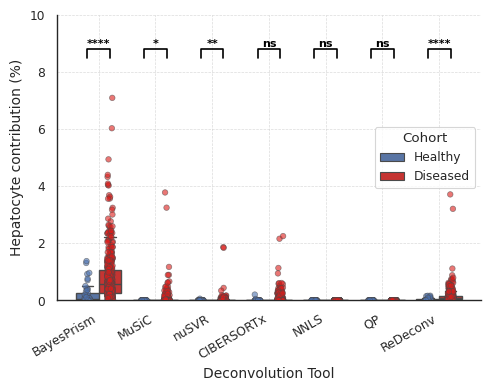

In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
import matplotlib as mpl

# --- illustrator-friendly ---
mpl.rcParams["svg.fonttype"] = "none"
mpl.rcParams["font.family"] = "DejaVu Sans"
mpl.rcParams["font.sans-serif"] = ["DejaVu Sans"]

def pval_to_star(p):
    if pd.isna(p): return ""
    if p < 0.0001: return "****"
    elif p < 0.001: return "***"
    elif p < 0.01: return "**"
    elif p < 0.05: return "*"
    else: return "ns"

def add_bracket(ax, x1, x2, y, text, height):
    ax.plot([x1, x1, x2, x2], [y, y+height, y+height, y], lw=1.2, c="black")
    ax.text((x1+x2)/2, y+height, text, ha="center", va="bottom",
            fontsize=8, fontweight="bold", color="black")

# ---------- Load Chalasani decon results ----------
files = {
    "Healthy": "TSP-BDa_Outer_300_1500_10-Chalasani_Healthy/merged_normalised_results_Chalasani_Healthy.txt",
    "NAFLD":   "TSP-BDa_Outer_300_1500_10-Chalasani_NAFLD/merged_normalised_results_Chalasani_NAFLD.txt",
    "NASH":    "TSP-BDa_Outer_300_1500_10-Chalasani_NASH/merged_normalised_results_Chalasani_NASH.txt"
}

dfs = []
for cohort, path in files.items():
    df = pd.read_csv(path, sep="\t")
    df["Cohort"] = cohort
    dfs.append(df)

decon = pd.concat(dfs, ignore_index=True)

# Healthy vs Diseased (NAFLD+NASH)
decon["Cohort_group"] = np.where(decon["Cohort"].eq("Healthy"), "Healthy", "Diseased")
decon["Cohort_group"] = pd.Categorical(decon["Cohort_group"],
                                       categories=["Healthy", "Diseased"], ordered=True)

# ---------- Long format ----------
exclude_cols = ["Sample", "Method", "Cohort", "Cohort_group"]
celltype_cols = [c for c in decon.columns if c not in exclude_cols]

long_df = decon.melt(
    id_vars=["Sample", "Method", "Cohort", "Cohort_group"],
    value_vars=celltype_cols,
    var_name="CellType",
    value_name="Contribution"
)
long_df["Contribution"] = pd.to_numeric(long_df["Contribution"], errors="coerce")
long_df = long_df.dropna(subset=["Contribution"])

# ---------- Choose your cell type ----------
CELLTYPE = "hepatocyte"   # change to any exact column name from your file
ct_df = long_df[long_df["CellType"].eq(CELLTYPE)].copy()
if ct_df.empty:
    raise ValueError(f"No rows found for CellType='{CELLTYPE}'. Check spelling/case vs your columns.")

# ---------- Stats per tool ----------
tool_order = ["BayesPrism", "MuSiC", "nuSVR", "CIBERSORTx", "NNLS", "QP", "ReDeconv"]
ct_df["Method"] = pd.Categorical(ct_df["Method"], categories=tool_order, ordered=True)

stats = []
for method, df_m in ct_df.groupby("Method"):
    g = {k: v["Contribution"].values for k, v in df_m.groupby("Cohort_group")}
    if "Healthy" in g and "Diseased" in g and len(g["Healthy"]) and len(g["Diseased"]):
        _, p = mannwhitneyu(g["Healthy"], g["Diseased"], alternative="two-sided")
        stats.append({"Method": method, "pval": p})

stats_df = pd.DataFrame(stats)

# BH across tools (only the tests shown on this figure)
stats_df["pval_BH"] = np.nan
if not stats_df.empty:
    valid = stats_df["pval"].dropna()
    _, p_corr, _, _ = multipletests(valid, method="fdr_bh")
    stats_df.loc[valid.index, "pval_BH"] = p_corr

stats_df["Stars"] = stats_df["pval_BH"].apply(pval_to_star)

# ---------- Plot ----------
palette = {"Healthy": "#4C72B0", "Diseased": "#DD1C1A"}

sns.set_theme(style="white")
sns.set_context("paper", font_scale=1.0)

fig, ax = plt.subplots(figsize=(5, 4))

sns.boxplot(
    data=ct_df,
    x="Method", y="Contribution", hue="Cohort_group",
    palette=palette, dodge=True, showfliers=False, ax=ax
)
sns.stripplot(
    data=ct_df,
    x="Method", y="Contribution", hue="Cohort_group",
    palette=palette, dodge=True, jitter=True, alpha=0.6,
    linewidth=0.5, size=4, ax=ax
)

# keep one legend
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:2], labels[:2], title="Cohort", frameon=True)

# bracket positions for 2 hues
hue_offsets = {"Healthy": -0.20, "Diseased": 0.20}

ax.set_ylim(0, 10)

# y positioning based on data range
y0, y1 = ax.get_ylim()
yr = max(y1 - y0, 1e-6)
pad = 0.06 * yr
base_y = 8.5      # bracket baseline
height = 0.3     # bracket height

# map tool->x
xticks = ax.get_xticks()
xticklabels = [t.get_text() for t in ax.get_xticklabels()]
tool_to_x = dict(zip(xticklabels, xticks))

for _, r in stats_df.iterrows():
    tool = str(r["Method"])
    if tool not in tool_to_x:
        continue
    x = tool_to_x[tool]
    x1 = x + hue_offsets["Healthy"]
    x2 = x + hue_offsets["Diseased"]
    add_bracket(ax, x1, x2, base_y, r["Stars"], height)

# expand y-limit 
#ax.set_ylim(y0, max(y1, base_y + 2*height))

ax.set_xlabel("Deconvolution Tool", fontsize=10)
ax.set_ylabel("Hepatocyte contribution (%)", fontsize=10)
ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
sns.despine()
plt.tight_layout()

plt.savefig("Healthy_vs_Diseased_Chalasani_Hepatocyte.svg", format="svg", bbox_inches="tight")
plt.show()
